# Comparative Analysis — Pocket2Mol vs DiffSBDD

This notebook compares molecules generated by two structure-based generative models:
- **Pocket2Mol** — autoregressive, atom-by-atom generation (SE(3)-equivariant GNN)
- **DiffSBDD** — diffusion-based, all-at-once generation (equivariant score network)

Both models targeted the A2A adenosine receptor binding pocket (PDB: 4EIY).

---
> **Input:** `results/pocket2mol_generated.csv` and `results/diffsbdd_generated.csv`  
> **Output:** Comparison figures in `figures/`

## 1. Load Libraries

In [1]:
import pandas as pd                              # data handling and tables
import matplotlib.pyplot as plt                  # plots and histograms
import numpy as np                               # numerical calculations
from rdkit import Chem                           # molecule parsing
from rdkit.Chem import DataStructs               # Tanimoto similarity
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator  # fingerprints
import warnings
warnings.filterwarnings('ignore')                # suppress warnings

print("Libraries loaded!")

Libraries loaded!


## 2. Load Data

Load the pre-calculated molecular properties for both tools.

In [2]:
# Load results from both generative models
# These CSVs were produced by 03a and 03b notebooks
p2m = pd.read_csv('results/pocket2mol_generated.csv')   # Pocket2Mol results
dif = pd.read_csv('results/diffsbdd_generated.csv')     # DiffSBDD results

print(f"Pocket2Mol molecules: {len(p2m)}")
print(f"DiffSBDD molecules:   {len(dif)}")
print(f"\nColumns: {p2m.columns.tolist()}")

Pocket2Mol molecules: 113
DiffSBDD molecules:   28

Columns: ['smiles', 'valid', 'MW', 'LogP', 'HBA', 'HBD', 'TPSA', 'RotBonds', 'QED', 'SA_score', 'Lipinski', 'max_tanimoto', 'nearest_active']


## 3. Summary Statistics Comparison

Side-by-side comparison of key molecular properties between the two tools.

In [4]:
# Compare key statistics side by side
# mean = average value across all molecules
# std = standard deviation = how spread out the values are
props = ['MW', 'LogP', 'QED', 'SA_score', 'TPSA', 'HBA', 'HBD', 'max_tanimoto']

# Calculate mean ± std for each property
# round(3) = 3 decimal places
# astype(str) = convert number to text so we can combine with ' ± '
comparison = pd.DataFrame({
    'Pocket2Mol (mean±std)': p2m[props].mean().round(3).astype(str) + ' ± ' + p2m[props].std().round(3).astype(str),
    'DiffSBDD (mean±std)':   dif[props].mean().round(3).astype(str) + ' ± ' + dif[props].std().round(3).astype(str),
})

# Display as table — Jupyter renders DataFrames automatically as HTML tables
comparison

,Pocket2Mol (mean±std),DiffSBDD (mean±std)
MW,294.524 ± 75.294,247.75 ± 93.993
LogP,2.055 ± 1.288,2.004 ± 1.569
QED,0.721 ± 0.13,0.599 ± 0.116
SA_score,3.522 ± 1.161,4.712 ± 0.907
TPSA,66.68 ± 25.447,34.5 ± 20.486
HBA,3.451 ± 1.382,2.607 ± 1.315
HBD,1.416 ± 0.894,0.5 ± 0.839
max_tanimoto,0.16 ± 0.103,0.104 ± 0.023


## 4. Property Distribution Comparison

Overlaid histograms comparing molecular property distributions between 
<span style="color:steelblue">**Pocket2Mol (blue)**</span> and 
<span style="color:orange">**DiffSBDD (orange)**</span>. 

This allows visual comparison of how each tool explores chemical space.

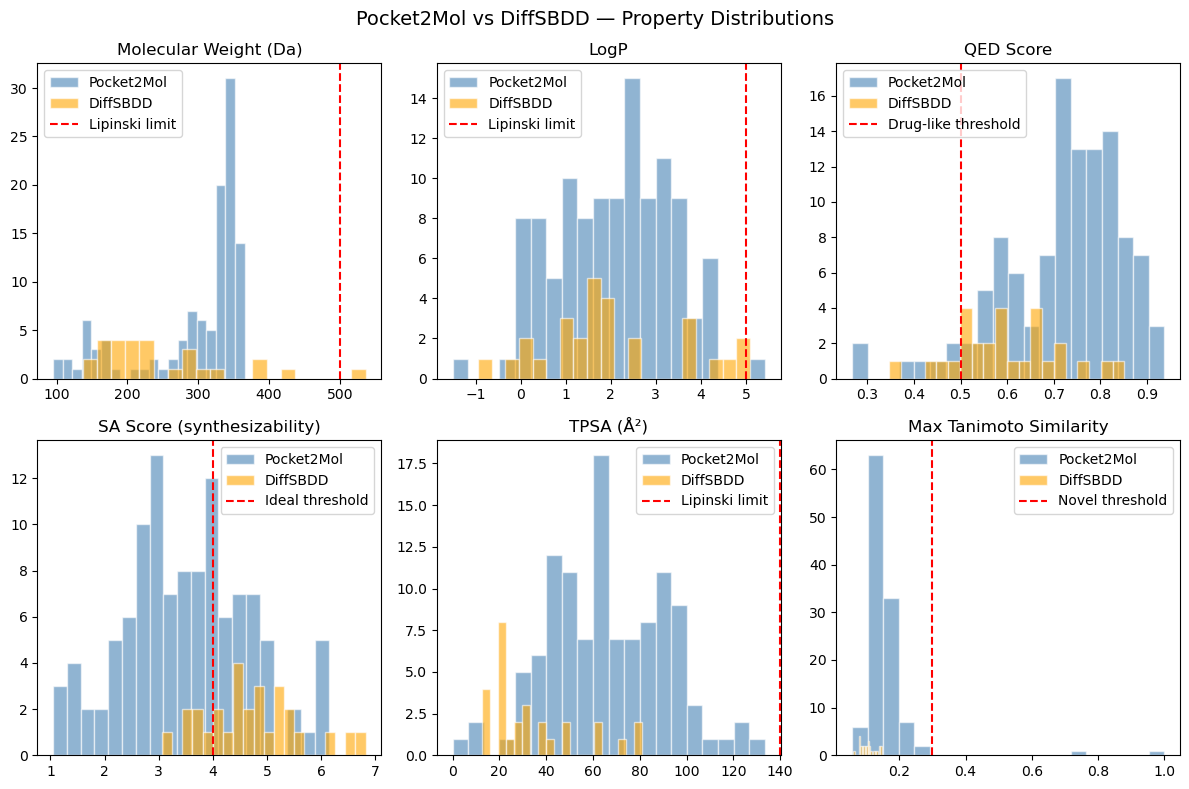

Saved to figures/


In [5]:
# Overlaid histograms for visual comparison of both tools
# alpha=0.6 = 60% opacity — allows bars to overlap and both be visible
fig, axes = plt.subplots(2, 3, figsize=(12, 8))  # 2 rows, 3 columns
fig.suptitle('Pocket2Mol vs DiffSBDD — Property Distributions', fontsize=14)

# --- MW: ideal range 150-500 Da ---
axes[0,0].hist(p2m['MW'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[0,0].hist(dif['MW'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[0,0].axvline(500, color='red', linestyle='--', label='Lipinski limit')  # max 500 Da
axes[0,0].set_title('Molecular Weight (Da)')
axes[0,0].legend()

# --- LogP: ideal range -0.4 to 5.6 ---
axes[0,1].hist(p2m['LogP'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[0,1].hist(dif['LogP'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[0,1].axvline(5, color='red', linestyle='--', label='Lipinski limit')    # max LogP 5
axes[0,1].set_title('LogP')
axes[0,1].legend()

# --- QED: >0.5 = drug-like, 1.0 = ideal ---
axes[0,2].hist(p2m['QED'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[0,2].hist(dif['QED'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[0,2].axvline(0.5, color='red', linestyle='--', label='Drug-like threshold')
axes[0,2].set_title('QED Score')
axes[0,2].legend()

# --- SA Score: 1=easy to synthesize, 10=very hard ---
axes[1,0].hist(p2m['SA_score'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[1,0].hist(dif['SA_score'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[1,0].axvline(4, color='red', linestyle='--', label='Ideal threshold')   # ≤4 = good
axes[1,0].set_title('SA Score (synthesizability)')
axes[1,0].legend()

# --- TPSA: measures membrane permeability, <140 Å² = drug-like ---
axes[1,1].hist(p2m['TPSA'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[1,1].hist(dif['TPSA'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[1,1].axvline(140, color='red', linestyle='--', label='Lipinski limit')
axes[1,1].set_title('TPSA (Å²)')
axes[1,1].legend()

# --- Tanimoto: <0.3 = novel, >0.85 = same scaffold as known drug ---
axes[1,2].hist(p2m['max_tanimoto'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[1,2].hist(dif['max_tanimoto'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[1,2].axvline(0.3, color='red', linestyle='--', label='Novel threshold')
axes[1,2].set_title('Max Tanimoto Similarity')
axes[1,2].legend()

plt.tight_layout()   # automatically adjust spacing between subplots
plt.savefig('figures/comparison_property_distributions.png', dpi=150)  # save high quality
plt.show()
print("Saved to figures/")

## 5. Lipinski Compliance Comparison

Percentage of molecules passing Lipinski's Rule of Five (≤1 violation).

Pocket2Mol: 113/113 (100.0%) Lipinski compliant
DiffSBDD:   28/28 (100.0%) Lipinski compliant


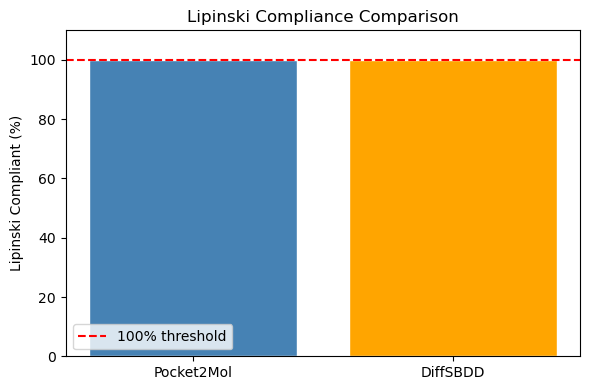

Saved to figures/


In [6]:
# Compare Lipinski compliance between both tools
# Lipinski <= 1 means at most 1 rule violated = drug-like molecule
p2m_compliant = (p2m['Lipinski'] <= 1).sum()   # count compliant molecules in Pocket2Mol
dif_compliant = (dif['Lipinski'] <= 1).sum()   # count compliant molecules in DiffSBDD

# Calculate percentages — how many % of generated molecules are drug-like
p2m_pct = 100 * p2m_compliant / len(p2m)       # Pocket2Mol percentage
dif_pct = 100 * dif_compliant / len(dif)       # DiffSBDD percentage

print(f"Pocket2Mol: {p2m_compliant}/{len(p2m)} ({p2m_pct:.1f}%) Lipinski compliant")
print(f"DiffSBDD:   {dif_compliant}/{len(dif)} ({dif_pct:.1f}%) Lipinski compliant")

# Bar chart comparing compliance percentages
fig, ax = plt.subplots(figsize=(6, 4))   # single plot, 6x4 inches
ax.bar(['Pocket2Mol', 'DiffSBDD'],       # x axis labels
       [p2m_pct, dif_pct],               # bar heights = percentages
       color=['steelblue', 'orange'],    # matching colors from histograms above
       edgecolor='white')
ax.set_ylabel('Lipinski Compliant (%)')  # y axis label
ax.set_title('Lipinski Compliance Comparison')
ax.set_ylim(0, 110)                      # y axis 0-110% so 100% bar fits nicely
ax.axhline(100, color='red', linestyle='--', label='100% threshold')  # ideal line
ax.legend()

plt.tight_layout()
plt.savefig('figures/comparison_lipinski.png', dpi=150)  # save high quality
plt.show()
print("Saved to figures/")

## 6. Tanimoto Similarity Comparison

Comparing novelty of generated molecules vs known A2A actives.
Lower Tanimoto = more novel chemotypes.

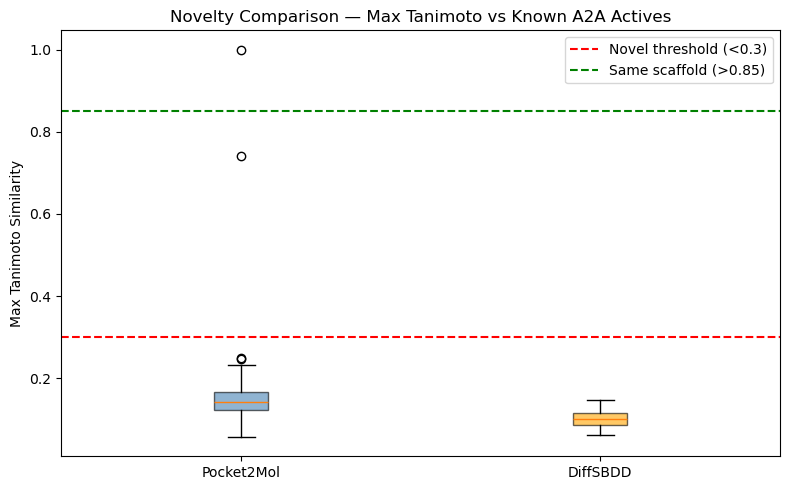

Saved to figures/


In [8]:
# Side-by-side boxplot comparing Tanimoto distributions
# Boxplot shows: median (middle line), 25%-75% range (box), min-max (whiskers), outliers (dots)
fig, ax = plt.subplots(figsize=(8, 5))

# Create boxplot — returns dictionary of plot elements
bp = ax.boxplot(
    [p2m['max_tanimoto'], dif['max_tanimoto']],    # data: list of two arrays
    labels=['Pocket2Mol', 'DiffSBDD'],              # x axis labels
    patch_artist=True,                              # enable colored boxes
)

# Color boxes individually using the returned dictionary
# bp['boxes'] = list of box patches, one per group
bp['boxes'][0].set_facecolor('steelblue')   # Pocket2Mol = blue
bp['boxes'][0].set_alpha(0.6)               # 60% transparency
bp['boxes'][1].set_facecolor('orange')      # DiffSBDD = orange
bp['boxes'][1].set_alpha(0.6)               # 60% transparency

# Reference lines for interpretation
ax.axhline(0.3, color='red', linestyle='--', label='Novel threshold (<0.3)')
ax.axhline(0.85, color='green', linestyle='--', label='Same scaffold (>0.85)')

ax.set_ylabel('Max Tanimoto Similarity')
ax.set_title('Novelty Comparison — Max Tanimoto vs Known A2A Actives')
ax.legend()

plt.tight_layout()
plt.savefig('figures/comparison_tanimoto_boxplot.png', dpi=150)
plt.show()
print("Saved to figures/")

## 7. Results Summary

In [9]:
# Final comparison summary table
# Brings together the most important metrics from both tools in one place
summary = pd.DataFrame({
    'Metric': [
        'Molecules generated',       # total valid molecules
        'Lipinski compliant',         # drug-like molecules (<=1 violation)
        'Mean QED',                   # average drug-likeness score (0-1)
        'Mean SA Score',              # average synthesizability (1-10, lower=better)
        'Mean Tanimoto',              # average similarity to known A2A actives
        'Identical to known active',  # molecules with Tc=1.0 (exact match)
    ],
    'Pocket2Mol': [
        f"{len(p2m)}",                                    # total molecules
        f"{(p2m['Lipinski']<=1).sum()} (100%)",           # compliant count
        f"{p2m['QED'].mean():.3f}",                       # mean QED
        f"{p2m['SA_score'].mean():.3f}",                  # mean SA score
        f"{p2m['max_tanimoto'].mean():.3f}",              # mean Tanimoto
        f"{(p2m['max_tanimoto']==1.0).sum()}",            # identical count
    ],
    'DiffSBDD': [
        f"{len(dif)}",                                    # total molecules
        f"{(dif['Lipinski']<=1).sum()} (100%)",           # compliant count
        f"{dif['QED'].mean():.3f}",                       # mean QED
        f"{dif['SA_score'].mean():.3f}",                  # mean SA score
        f"{dif['max_tanimoto'].mean():.3f}",              # mean Tanimoto
        f"{(dif['max_tanimoto']==1.0).sum()}",            # identical count
    ]
})

# Set Metric column as index for cleaner table display in Jupyter
summary = summary.set_index('Metric')
summary

,Pocket2Mol,DiffSBDD
Metric,,
Molecules generated,113,28
Lipinski compliant,113 (100%),28 (100%)
Mean QED,0.721,0.599
Mean SA Score,3.522,4.712
Mean Tanimoto,0.160,0.104
Identical to known active,1,0


## 8. Discussion

### Pocket2Mol vs DiffSBDD — Critical Comparison

**Molecules Generated (113 vs 28)**  
Pocket2Mol produced significantly more molecules (113 vs 28). However, this 
difference partly reflects the limited SDF output available from DiffSBDD 
rather than an inherent limitation of the model itself.

**Drug-likeness — QED (0.721 vs 0.599)**  
Both tools produced drug-like molecules (QED > 0.5). Pocket2Mol achieved a 
higher mean QED (0.721), exceeding the average QED of marketed drugs (~0.67). 
DiffSBDD molecules were still drug-like but scored lower on average (0.599).

**Synthesizability — SA Score (3.522 vs 4.712)**  
Pocket2Mol generated more synthetically accessible molecules (SA Score ≤ 4), 
suggesting these candidates would be easier to produce in the laboratory. 
DiffSBDD molecules scored higher (mean 4.712), indicating greater synthetic 
complexity — potentially challenging for experimental validation.

**Novelty — Tanimoto Similarity (0.160 vs 0.104)**  
Both tools generated novel chemotypes (mean Tanimoto < 0.3). DiffSBDD produced 
more structurally diverse molecules (0.104), suggesting it explores a broader 
chemical space. Pocket2Mol molecules showed slightly higher similarity to known 
A2A actives (0.160), which may indicate better A2A relevance — one molecule was 
identical to the known antagonist AZD4635 (Tc = 1.0).

**Lipinski Compliance (100% vs 100%)**  
Both tools achieved perfect Lipinski compliance, confirming that both generative 
models have learned to produce orally bioavailable drug-like molecules.

**Overall Recommendation**  
Pocket2Mol appears better suited for A2A-targeted drug discovery due to higher 
drug-likeness, better synthesizability, and closer alignment with known A2A 
pharmacophores. DiffSBDD may be more valuable for exploring novel chemical space 
in early-stage discovery campaigns where structural novelty is prioritized.

**Overall Recommendation**  
Based on the current dataset, Pocket2Mol appears better suited for A2A-targeted 
drug discovery due to higher drug-likeness, better synthesizability, and closer 
alignment with known A2A pharmacophores. DiffSBDD may be more valuable for 
exploring novel chemical space in early-stage discovery campaigns where structural 
novelty is prioritized.

> **Caveat:** DiffSBDD comparison is based on a limited sample (28 molecules). 
> Conclusions may change with the complete dataset.